# Framework-agnostic sweeps (scikit-learn, no torch)

`MultiRunMetricsWorkflow` never inspects your model — it sweeps configurations
and collects the `dict` your `task` returns. So you can train a **scikit-learn**
model inside `task` (no torch, no Lightning) and still get a labeled
`xarray.Dataset` back, exactly as with a torch model. mushin needs no
scikit-learn integration for this; the sweep layer is neutral.

In [ ]:
from __future__ import annotations

import tempfile

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from mushin import multirun
from mushin.workflows import MultiRunMetricsWorkflow

A fixed, seeded synthetic classification problem, split per seed.

In [ ]:
def split(seed: int):
    x, y = make_classification(
        n_samples=400, n_features=20, n_informative=5, random_state=seed
    )
    return train_test_split(x, y, test_size=0.25, random_state=seed)

Sweep the inverse-regularization strength `C` across seeds; the returned dict
populates the dataset — no torch, no checkpoint to save.

In [ ]:
class LogRegCSweep(MultiRunMetricsWorkflow):
    @staticmethod
    def task(C: float, seed: int) -> dict:
        x_train, x_test, y_train, y_test = split(seed)
        model = LogisticRegression(C=C, max_iter=1000, random_state=seed)
        model.fit(x_train, y_train)
        return dict(accuracy=float(model.score(x_test, y_test)))


wf = LogRegCSweep()
wf.run(
    C=multirun([0.01, 0.1, 1.0, 10.0]),
    seed=multirun([0, 1, 2]),
    working_dir=tempfile.mkdtemp(),
)
ds = wf.to_xarray()
ds

[2026-07-14 20:45:12,256][HYDRA] Launching 12 jobs locally


[2026-07-14 20:45:12,257][HYDRA] 	#0 : +C=0.01 +seed=0


[2026-07-14 20:45:12,334][HYDRA] 	#1 : +C=0.01 +seed=1


[2026-07-14 20:45:12,396][HYDRA] 	#2 : +C=0.01 +seed=2


[2026-07-14 20:45:12,462][HYDRA] 	#3 : +C=0.1 +seed=0


...

[2026-07-14 20:45:12,898][HYDRA] 	#10 : +C=10.0 +seed=1


/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  r

[2026-07-14 20:45:12,959][HYDRA] 	#11 : +C=10.0 +seed=2


/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(


<xarray.Dataset> Size: 152B
Dimensions:   (C: 4, seed: 3)
Coordinates:
  * C         (C) float64 32B 0.01 0.1 1.0 10.0
  * seed      (seed) int64 24B 0 1 2
Data variables:
    accuracy  (C, seed) float64 96B 0.85 0.66 0.92 0.85 ... 0.93 0.85 0.65 0.93
Attributes:
    provenance:  {"timestamp": "2026-07-15T00:45:12.297416+00:00", "python": ...

Same labeled dataset as the torch sweep in notebook 01 — plot accuracy vs `C`.

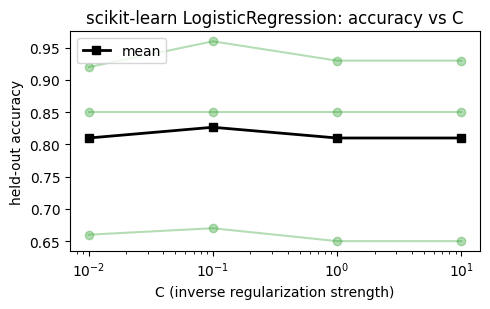

In [ ]:
import matplotlib.pyplot as plt

mean_acc = ds["accuracy"].mean("seed")
fig, ax = plt.subplots(figsize=(5, 3.2))
for s in ds["seed"].values:
    ax.plot(ds["C"].values, ds["accuracy"].sel(seed=s).values, "o-",
            alpha=0.35, color="tab:green")
ax.plot(ds["C"].values, mean_acc.values, "ks-", lw=2, label="mean")
ax.set_xscale("log")
ax.set_xlabel("C (inverse regularization strength)")
ax.set_ylabel("held-out accuracy")
ax.set_title("scikit-learn LogisticRegression: accuracy vs C")
ax.legend()
fig.tight_layout()
plt.show()

**See also**

- [Notebook 01](01_sweep_to_dataset.ipynb) — the identical flow with a torch
  model.
- [Core concepts](../concepts.md) — why the sweep layer is framework-agnostic.